# Credit Risk Default

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import export_graphviz
from sklearn.preprocessing import OrdinalEncoder 
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from graphviz import Source

# Why does this issue matter? <br>
- Credit Default Prediction is a real world, high stakes problem
- False Negatives (Loaning the person, but it is a defaulter), this cost the banks money 
- False Positive (Not loaning the person, even though he is not a defaulter), this can be unfair to customers

# The metric we will be using: F1-Score & ROC-AUC 
- Because default only make up about 22% of my dataset (it is imbalance), thus the stated metric would be useful

# Load the dataset 

In [3]:
df_raw = pd.read_csv('credit_risk_dataset.csv')

In [4]:
df_raw

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


# Exploratory Data Analysis (EDA): What the data is telling me? <br>
Before building any models, lets understand the characteristics of our borrowers. <br>
- Does income dictate defaults? 
- Are riskier loan grades actually defaulting more? 

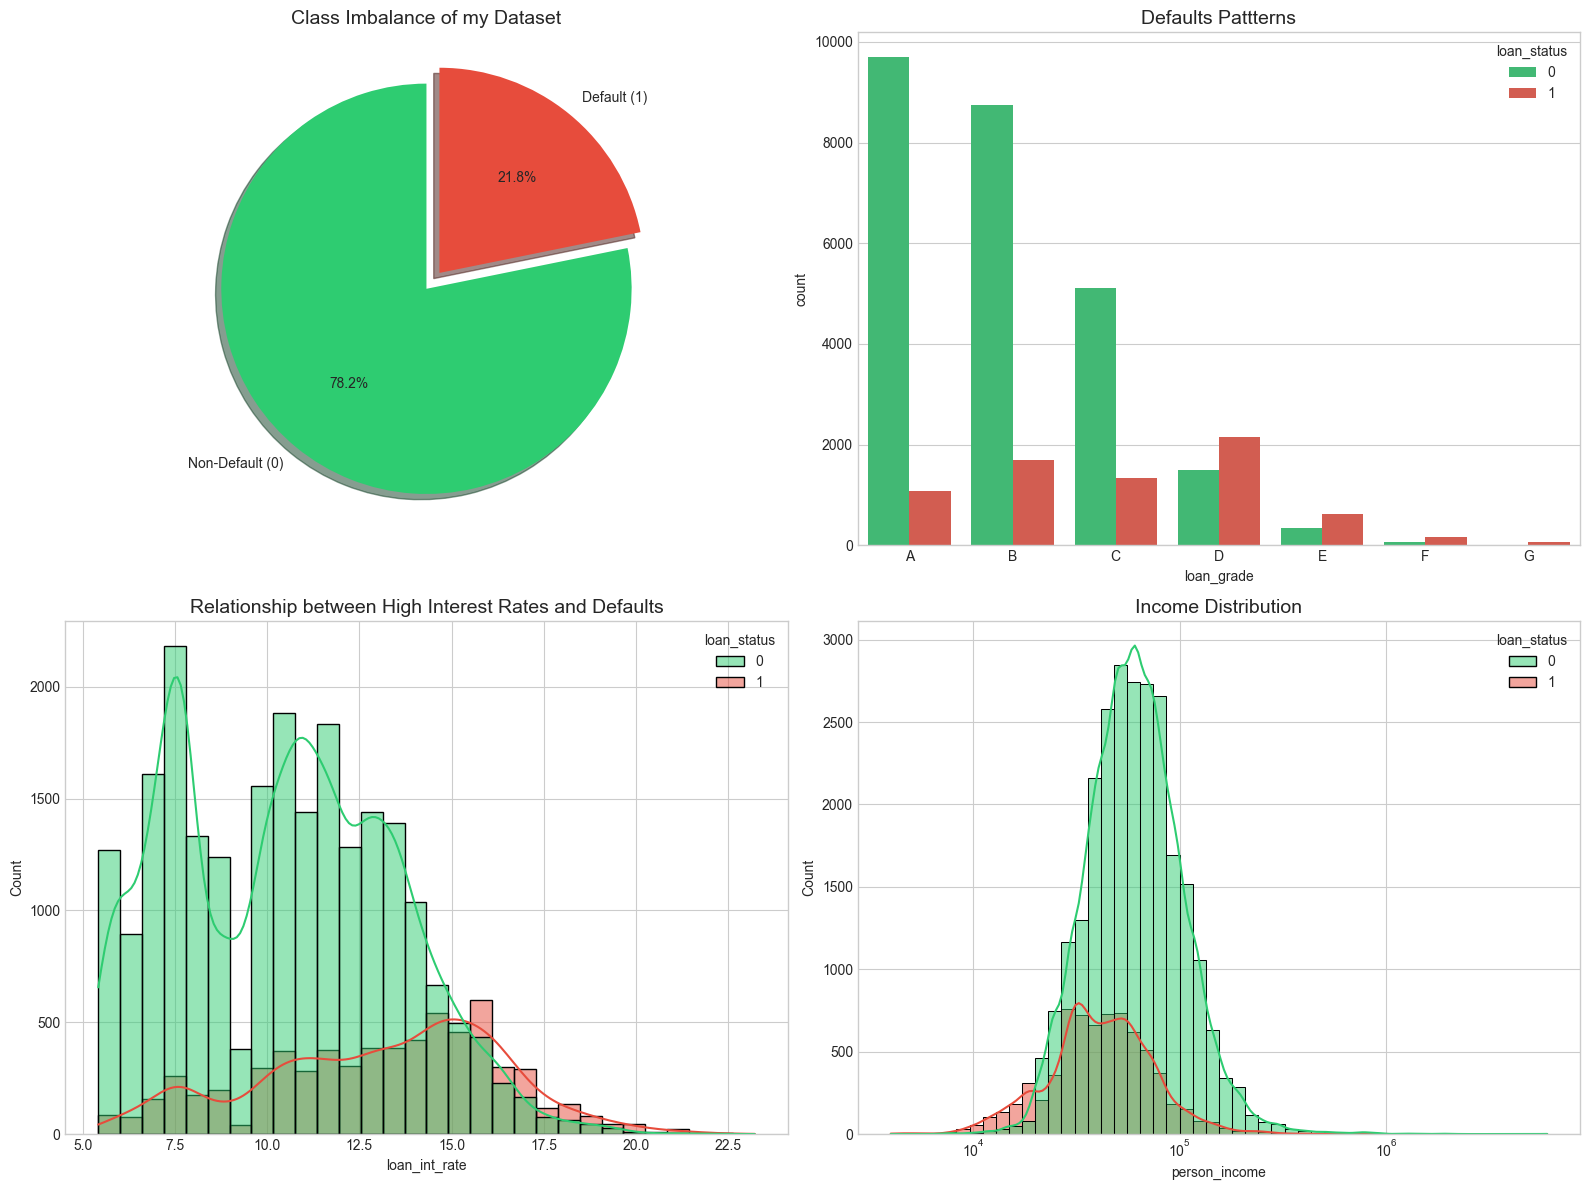

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
palette = ['#2ecc71', '#e74c3c'] # Green for Paid, Red for Default

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top Right Graph
df_raw['loan_status'].value_counts().plot(
    kind='pie', 
    ax=axes[0, 0], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=palette,
    labels=['Non-Default (0)', 'Default (1)'], 
    explode=(0, 0.1), 
    shadow=True
)
axes[0, 0].set_title('Class Imbalance of my Dataset', fontsize=14)
axes[0, 0].set_ylabel('')

# Top Left Graph
sns.countplot(data=df_raw, 
              x='loan_grade', 
              hue='loan_status', 
              ax=axes[0, 1], 
              palette=palette, 
              order=sorted(df_raw['loan_grade'].dropna().unique()))

axes[0, 1].set_title('Defaults Pattterns', fontsize=14)


sns.histplot(data=df_raw, 
             x='loan_int_rate', 
             hue='loan_status', 
             ax=axes[1, 0], 
             kde=True, 
             palette=palette, bins=30)
axes[1, 0].set_title('Relationship between High Interest Rates and Defaults', fontsize=14)


sns.histplot(data=df_raw, 
             x='person_income', 
             hue='loan_status', 
             ax=axes[1, 1], 
             kde=True, 
             palette=palette, 
             bins=50, 
             log_scale=True)
axes[1, 1].set_title('Income Distribution', fontsize=14)

plt.tight_layout()
plt.show()

# plt.figure(figsize=(10, 8))
# numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
# sns.heatmap(df_raw[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
# plt.title('Feature Correlation Heatmap', fontsize=14)
# plt.show()

# Columns Breakdown 
1. Age <br>
2. Annual Income
3. Home Ownership
4. Employment Length (in years)
5. Purpose of loan
6. Loan Grade (A, B, C, D, E, F, G)
7. How much the fella wanna loan 
8. Interest rate 
9. 0 is non default, 1 is default
10. His loan as a percentage of his annual income 
11. Default before yes/no
12. How long he has had a credit record

In [5]:
df_raw.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df_raw.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

# Data Cleaning

In [7]:
def load_and_clean():
    # Loading the data set 
    df = pd.read_csv('credit_risk_dataset.csv')

    # Remove any age >= 80, unrealistic for a loan applicant 
    df = df[df["person_age"] <= 80] 

    # Drop all rows where the employment length > age
    df = df[(df['person_emp_length'] <= df['person_age']) | (df['person_emp_length'].isna()) ]

    # Filling in all my missing values with median, 2 columns have NA values (person_emp_length, loan_int_rate)
    df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

    # Encode categorical columns
    # Ordinal Encoder for loan_grade
    ode = OrdinalEncoder(categories = [["A", "B", "C", "D", "E", "F", "G"]])
    df[['loan_grade']] = ode.fit_transform(df[['loan_grade']])

    df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({"Y": 1,
                                                                           "N": 0}) 

    df = pd.get_dummies(df, columns = ['person_home_ownership', 'loan_intent'], drop_first = True)

    return df

# Lets have a look at our new DataFrame

In [8]:
df = load_and_clean()
display(df)

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,1.0,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25,9600,1.0,2.0,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23,65500,4.0,2.0,35000,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
4,24,54400,8.0,2.0,35000,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False
5,21,9900,2.0,0.0,2500,7.14,1,0.25,0,2,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,2.0,5800,13.16,0,0.11,0,30,False,False,False,False,False,False,True,False
32577,54,120000,4.0,0.0,17625,7.49,0,0.15,0,19,False,False,False,False,False,False,True,False
32578,65,76000,3.0,1.0,35000,10.99,1,0.46,0,28,False,False,True,False,True,False,False,False
32579,56,150000,5.0,1.0,15000,11.48,0,0.10,0,26,False,False,False,False,False,False,True,False


# Evalution Function

In [9]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    f1score = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  F1-score : {f1score:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(pd.DataFrame(report))
    #return {"accuracy": round(acc, 4), 
    # "roc_auc": round(auc, 4), 
    # "report": report}

# Splitting of data

In [10]:
X = df.drop(columns = ['loan_status'])
y = df['loan_status']

In [11]:
X_train, X_test, y_train, y_test = (train_test_split(X, 
                                                     y, 
                                                     test_size=0.2, 
                                                     random_state=42, 
                                                     stratify=y))

# Model 1 <br>
- Base line model

In [12]:
m1 = DecisionTreeClassifier(random_state = 42)
m1.fit(X_train, y_train)
print(evaluate("Model1 - Baseline", m1, X_test, y_test))


  Model1 - Baseline
  F1-score : 0.7409
  ROC-AUC  : 0.8399
                     0            1  accuracy    macro avg  weighted avg
precision     0.932548     0.720745  0.883653     0.826647      0.886319
recall        0.917534     0.762307  0.883653     0.839920      0.883653
f1-score      0.924980     0.740943  0.883653     0.832962      0.884811
support    5093.000000  1422.000000  0.883653  6515.000000   6515.000000
None


# Model 2
- Add in a few parameters

In [13]:
m2 = DecisionTreeClassifier(random_state = 42,
                            max_depth = 6,
                            min_samples_split = 50,
                            min_samples_leaf = 20
)
m2.fit(X_train, y_train)
print(evaluate("Model2 - Added Parameters", m2, X_test, y_test))


  Model2 - Added Parameters
  F1-score : 0.7633
  ROC-AUC  : 0.8938
                     0            1  accuracy    macro avg  weighted avg
precision     0.907928     0.944041  0.913277     0.925985      0.915810
recall        0.989397     0.640647  0.913277     0.815022      0.913277
f1-score      0.946913     0.763301  0.913277     0.855107      0.906837
support    5093.000000  1422.000000  0.913277  6515.000000   6515.000000
None


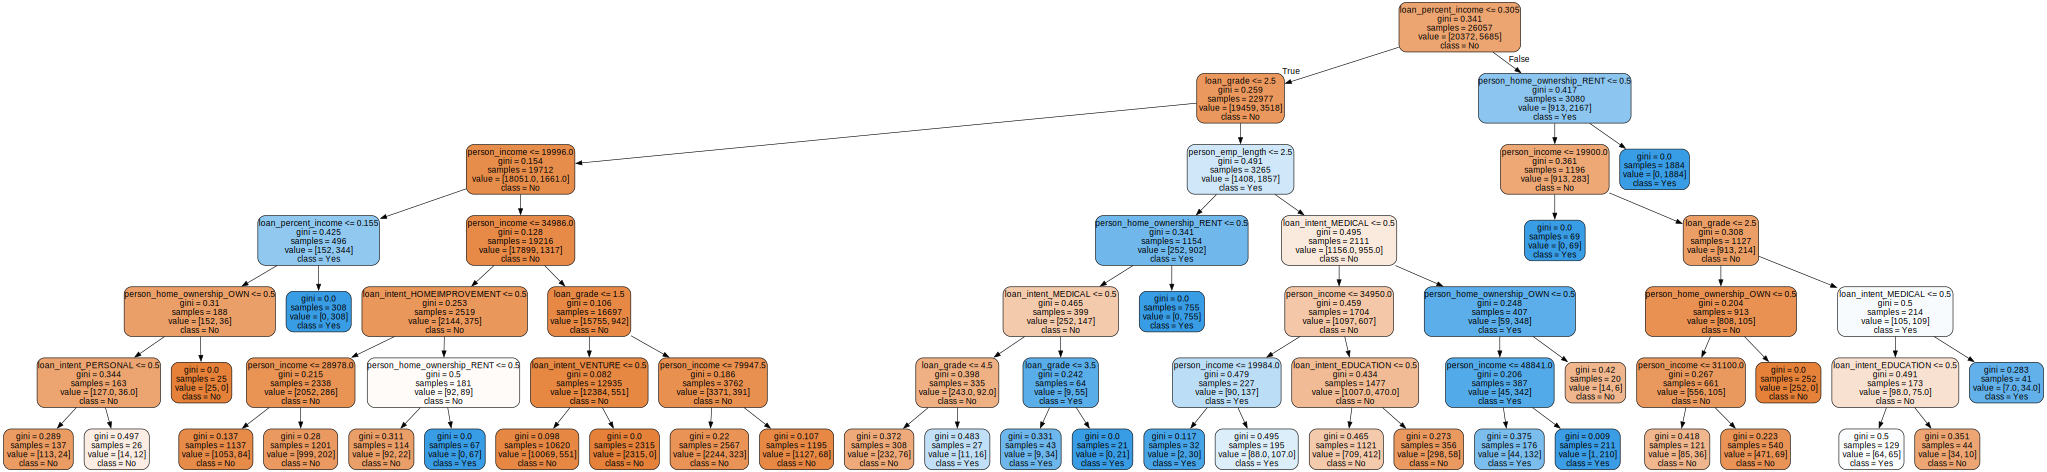

In [14]:
export_graphviz(
    m2,
    out_file = 'Model2.dot',
    feature_names = X.columns,
    class_names = ['No', 'Yes'],
    rounded = True,
    filled = True
)

Source.from_file("Model2.dot")

# Model 3 <br>
We will use optuna to tune our parameters:
- criterion 
- max_depth
- min_samples_split 
- min_samples_leaf

In [15]:
def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "random_state": 42,
    }

    clf = DecisionTreeClassifier(**params)
    clf.fit(X_train, y_train)

    return f1_score(y_test, clf.predict(X_test))

study = optuna.create_study(direction = 'maximize')
study.optimize(objective, 
               n_trials = 1000,
               show_progress_bar = False)

final_params = study.best_params
final_params['random_state'] = 42

m3 = DecisionTreeClassifier(**final_params)
m3.fit(X_train, y_train)
print(evaluate("Model3 - Optuna Tuned", m3, X_test, y_test))


[I 2026-04-14 00:37:15,846] A new study created in memory with name: no-name-1f1374e0-816e-48e4-9e9b-68cd40fc0cd2
[I 2026-04-14 00:37:15,899] Trial 0 finished with value: 0.8027653517690118 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 28, 'min_samples_leaf': 14}. Best is trial 0 with value: 0.8027653517690118.
[I 2026-04-14 00:37:15,955] Trial 1 finished with value: 0.8047524752475248 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 28, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8047524752475248.
[I 2026-04-14 00:37:15,998] Trial 2 finished with value: 0.8080229226361032 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 43, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.8080229226361032.
[I 2026-04-14 00:37:16,052] Trial 3 finished with value: 0.8016227180527383 and parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 15}. Best is trial 


  Model3 - Optuna Tuned
  F1-score : 0.8147
  ROC-AUC  : 0.9089
                     0            1  accuracy    macro avg  weighted avg
precision     0.924062     0.959048  0.929701     0.941555      0.931698
recall        0.991557     0.708158  0.929701     0.849857      0.929701
f1-score      0.956621     0.814725  0.929701     0.885673      0.925650
support    5093.000000  1422.000000  0.929701  6515.000000   6515.000000
None


# Confusion Matrix for Model 3

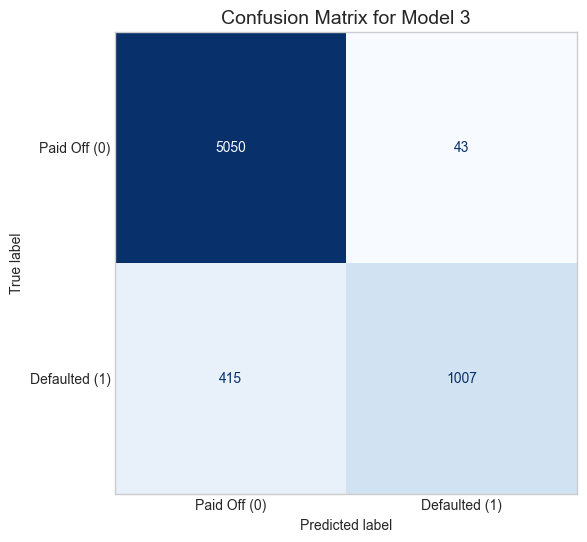

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    m3, X_test, y_test, 
    display_labels=['Paid Off (0)', 'Defaulted (1)'], 
    cmap='Blues', ax=ax, colorbar=False
)
plt.title("Confusion Matrix for Model 3", fontsize=14)
plt.grid(False)
plt.show()

In [17]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': m3.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', 
                                          ascending=True)

fig = px.bar(
    importance_df, 
    x = 'Importance', 
    y = 'Feature', 
    orientation = 'h',
    title = 'Model 3 Feature Importance',
    color = 'Importance',
    color_continuous_scale = 'Blues'
)

fig.update_layout(showlegend=False,
                  template = 'plotly_dark')
fig.show()

In [25]:

importances = m3.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', 
               ascending=False)

sorted_features = feature_importance_df['Feature'].tolist()

f1_scores = []
num_features_list = []

for i in range(1, len(sorted_features) + 1):
    top_n_features = sorted_features[:i]

    X_train_sub = X_train[top_n_features]
    X_test_sub = X_test[top_n_features]
    
    temp_model = DecisionTreeClassifier(**final_params)
    temp_model.fit(X_train_sub, y_train)
    
    preds = temp_model.predict(X_test_sub)
    score = f1_score(y_test, preds)
    
    f1_scores.append(score)
    num_features_list.append(i)

tradeoff_df = pd.DataFrame({
    'Number of Features': num_features_list, 
    'F1-Score': f1_scores
})

fig = px.line(
    tradeoff_df, 
    x = 'Number of Features', 
    y = 'F1-Score', 
    markers = True, 
    title = 'Feature Selection Tradeoff for Model 3'
)


best_num = num_features_list[f1_scores.index(max(f1_scores))]
fig.add_vline(x=best_num, line_dash="dash", line_color="red", 
              annotation_text=f"Max F1 at {best_num} features")

fig.update_layout(
    xaxis_title="Number of Top Features Kept", 
    yaxis_title="F1-Score on Test Set",
    yaxis=dict(range=[min(f1_scores) - 0.05, max(f1_scores) + 0.02]),
    template = 'plotly_dark'
)
fig.show()

# Model 3 - Reduced Version

In [28]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': m3.feature_importances_
}).sort_values(by='Importance', ascending=True)
bottom_5_features = importance_df.head(4)['Feature'].tolist()

X_train_reduced = X_train.drop(columns=bottom_5_features)
X_test_reduced = X_test.drop(columns=bottom_5_features)

m3_reduced = DecisionTreeClassifier(**final_params)
m3_reduced.fit(X_train_reduced, y_train)
print(evaluate("Model 3 - Reduced Version", m3_reduced, X_test_reduced, y_test))


  Model 3 - Reduced Version
  F1-score : 0.8142
  ROC-AUC  : 0.9089
                     0            1  accuracy    macro avg  weighted avg
precision     0.923893     0.959009  0.929547     0.941451      0.931558
recall        0.991557     0.707454  0.929547     0.849506      0.929547
f1-score      0.956530     0.814245  0.929547     0.885388      0.925474
support    5093.000000  1422.000000  0.929547  6515.000000   6515.000000
None


# Model 4, Random Forest

In [19]:
m4 = RandomForestClassifier(
    n_estimators = 500,          # Increases the number of trees (default is 100) for more stable prediction
    n_jobs = -1,                 # Uses all available CPU cores to make training significantly faster
    random_state = 42
)

m4.fit(X_train, y_train)
print(evaluate("Model 4 - Random Forest", m4, X_test, y_test))


  Model 4 - Random Forest
  F1-score : 0.8244
  ROC-AUC  : 0.9328
                     0            1  accuracy    macro avg  weighted avg
precision     0.925210     0.979671  0.933845     0.952440      0.937097
recall        0.995877     0.711674  0.933845     0.853775      0.933845
f1-score      0.959243     0.824440  0.933845     0.891842      0.929821
support    5093.000000  1422.000000  0.933845  6515.000000   6515.000000
None


# Model 5: XGBoost Classifier

In [29]:
m5 = xgb.XGBClassifier(
        n_estimators = 300, 
        max_depth = 6, 
        learning_rate = 0.05,
        subsample = 0.8, 
        colsample_bytree = 0.8,
        use_label_encoder = False, 
        eval_metric = "logloss",
        random_state = 42, 
        n_jobs = -1
    )
m5.fit(X_train, y_train)
print(evaluate("Model 6: XGBoost", m5, X_test, y_test))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning:

[00:55:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.





  Model 6: XGBoost
  F1-score : 0.8252
  ROC-AUC  : 0.9445
                     0            1  accuracy    macro avg  weighted avg
precision     0.925689     0.977842  0.933998     0.951766      0.937072
recall        0.995484     0.713783  0.933998     0.854634      0.933998
f1-score      0.959319     0.825203  0.933998     0.892261      0.930046
support    5093.000000  1422.000000  0.933998  6515.000000   6515.000000
None


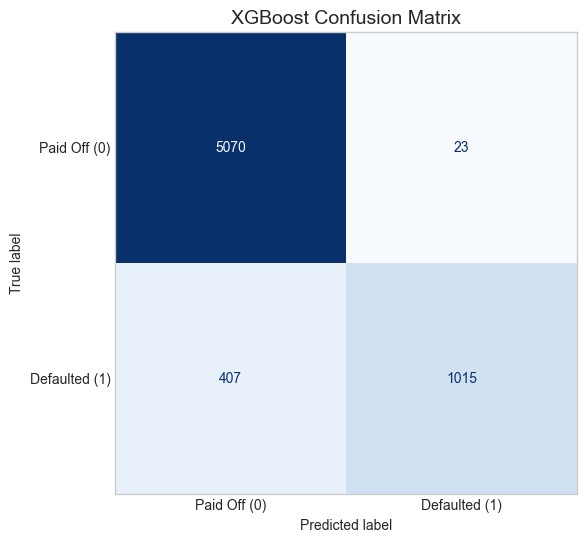

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    m5, X_test, y_test, 
    display_labels=['Paid Off (0)', 'Defaulted (1)'], 
    cmap='Blues', ax=ax, colorbar=False
)
plt.title("XGBoost Confusion Matrix", fontsize=14)
plt.grid(False)
plt.show()